In [3]:
%cd .

c:\Users\baklu\Documents\NTNU\IT3212


In [4]:
import tensorflow as tf
import pandas as pd
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader
import torch as nn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import os
import random
import ipykernel
from src.alignement import process_folder, align_face_bgr
from sklearn.decomposition import PCA
from src.pca import load_grayscale_faces, pca, plot_face_mean_eigenfaces_individual


## Raw Image

(np.float64(-0.5), np.float64(3887.5), np.float64(3887.5), np.float64(-0.5))

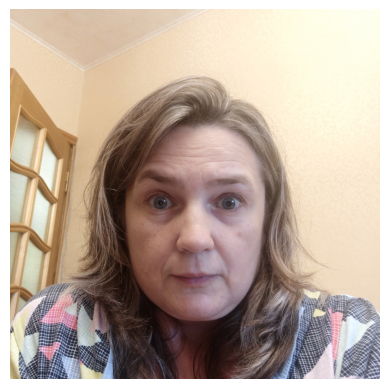

In [5]:
pth = "C:\\Users\\baklu\\Documents\\NTNU\\IT3212\\data\\mood_detection\\images\\13\\Fear.jpg"

image = cv2.imread(pth)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')

## Aligned by calibrating facial landmarks + greyscale

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

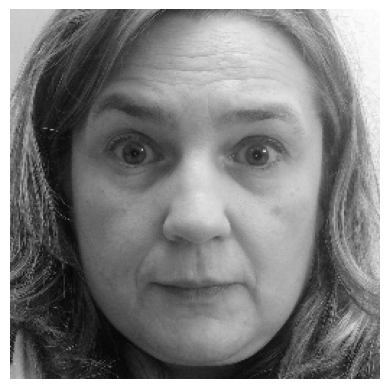

In [7]:
aligned = align_face_bgr(image)
aligned = cv2.cvtColor(aligned[0], cv2.COLOR_BGR2GRAY)
plt.imshow(aligned, cmap='gray')
plt.axis('off')

## Remove unnecesary parts of img

![](Fear_aligned_256.png)


Loaded 152 images of size 256x256.
PCA kept 50 components.
Explained variance (first 5): [1119.6953   527.2557   323.18518  138.03026  111.84432]


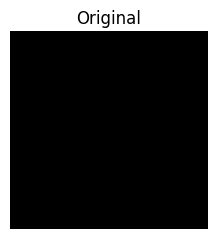

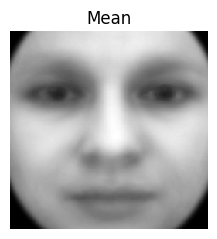

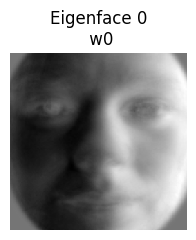

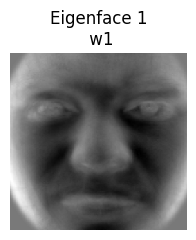

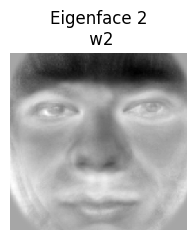

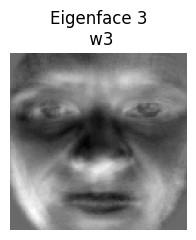

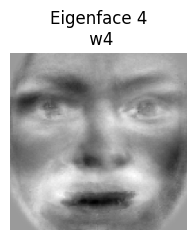

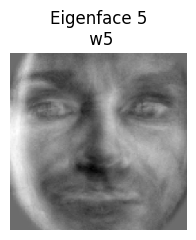

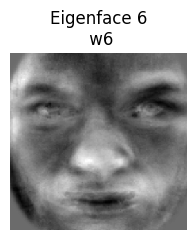

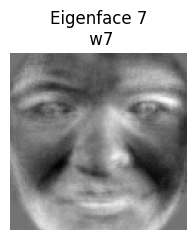

In [8]:
ROOT_DIR = "C:\\Users\\baklu\\Documents\\NTNU\\IT3212\\data\\mood_detection\\images_processed"



X, imgs, H, W, paths = load_grayscale_faces(ROOT_DIR)

# Choose how many principal components to keep (e.g., 50 or min(n_samples, n_pixels))
K = min(50, X.shape[0])  # sensible default
mean, components, explained_var, scores = pca(X, k=K)

print(f"Loaded {X.shape[0]} images of size {H}x{W}.")
print(f"PCA kept {components.shape[0]} components.")
print(f"Explained variance (first 5): {explained_var[:5]}")


plot_face_mean_eigenfaces_individual(aligned, mean, components, H, W, num_terms=8)